### Preparation

In [7]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from gather_ds import make_ds_add_feat, make_ds_add_year, metrics, make_ds_add_new

import warnings
warnings.filterwarnings("ignore")
import sys
import os
import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
import xgboost as xgb
from collections import Counter
import codecs, json
from geopy.distance import geodesic

from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder

In [8]:
data_meteo = pd.read_parquet("/home/teshbek/repos/Wind/data_mounted/weather_stations/data_meteo_full.parquet")
data_meteo.index=pd.to_datetime((data_meteo.index), format="%Y/%m/%d")
Altay_list = pd.read_table("Altay_list.csv", sep=',')

In [9]:
data_meteo

,Дата,Название метеостанции,Максимальная скорость,Средняя скорость ветра,Направление ветра,Температура воздуха по сухому терм-ру,Атмосферное давление на уровне станции,Атмосферное давление на уровне моря,Сумма осадков,Температура поверхности почвы,Парциальное давление водяного пара,Относительная влажность воздуха,Температура точки росы
1970-01-01 00:00:00.000000000,1965-12-31,Северо-Енисейский,NaN,4.0,200.0,-10.5,956.8,1022.2,NaN,-10.0,NaN,86.0,-12.0
1970-01-01 00:00:00.000000001,1965-12-31,Северо-Енисейский,NaN,4.0,200.0,-11.3,956.9,1022.5,NaN,-11.0,NaN,88.0,-12.0
1970-01-01 00:00:00.000000002,1965-12-31,Северо-Енисейский,NaN,2.0,200.0,-11.6,956.6,1022.6,NaN,-12.0,NaN,89.0,-13.0
1970-01-01 00:00:00.000000003,1966-01-01,Северо-Енисейский,NaN,4.0,200.0,-11.1,956.7,1022.4,1.0,-11.0,NaN,88.0,-12.0
1970-01-01 00:00:00.000000004,1966-01-01,Северо-Енисейский,NaN,3.0,200.0,-12.4,956.7,1022.6,NaN,-12.0,NaN,86.0,-14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.080769863,2021-01-30,Уэлен,10.0,3.0,324.0,-26.4,1030.7,1031.7,0.0,-29.8,0.53,73.0,-29.8
1970-01-01 00:00:00.080769864,2021-01-30,Уэлен,8.0,2.0,9.0,-28.4,1032.1,1033.1,0.0,-31.7,0.42,71.0,-31.9
1970-01-01 00:00:00.080769865,2021-01-31,Уэлен,5.0,2.0,10.0,-27.7,1033.5,1034.5,0.0,-27.7,0.45,71.0,-31.3
1970-01-01 00:00:00.080769866,2021-01-31,Уэлен,4.0,2.0,10.0,-29.1,1034.0,1035.0,0.0,-35.0,0.39,70.0,-32.8


In [5]:
data_meteo.insert(loc=0, column='day', value=data_meteo.index)
data_meteo['day'] = data_meteo['day'].dt.dayofyear

enc = OneHotEncoder()
enc.fit(np.array(data_meteo.day).reshape(-1, 1))

OneHotEncoder()

### Find Optimal Parameters

In [6]:
begin_of_ds_train = pd.to_datetime('1990-01-01')
# end_of_ds_train = pd.to_datetime('1998-12-31')
begin_of_ds_test = pd.to_datetime('2006-01-01')
end_of_ds_test = pd.to_datetime('2007-12-31')
endd = [pd.to_datetime('1991-12-31'), pd.to_datetime('1993-12-31'), pd.to_datetime('1995-12-31'), pd.to_datetime('1997-12-31'), pd.to_datetime('1999-12-31'), 
pd.to_datetime('2001-12-31'), pd.to_datetime('2003-12-31'), pd.to_datetime('2005-12-31')]
dic = {}
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])

for e in endd:
    X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, e, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
    clf_xgb.fit(X_train, y_train)
    dic[e] = metrics(clf_xgb, X_test, y_test)

ac_temp, pr_temp, re_temp, f_temp = [], [], [], []
for e in endd:
    ac_temp.append(dic[e][0])
    pr_temp.append(dic[e][1])
    re_temp.append(dic[e][2])
    f_temp.append(dic[e][3])

fig, ax = plt.subplots()
plt.title('Model performance from Size of Train', fontsize=14)
ax.plot(endd,ac_temp, label='accuracy')
ax.plot(endd,pr_temp, label='recall')
ax.plot(endd,re_temp, label='precision')
ax.plot(endd,f_temp, label='f1-score')
plt.xlabel('Size of Train')
plt.legend()
plt.show()

ValueError: cannot reshape array of size 0 into shape (0,newaxis)

In [ ]:
print('len ==', len(y_test))
print('ones:', y_test.sum())

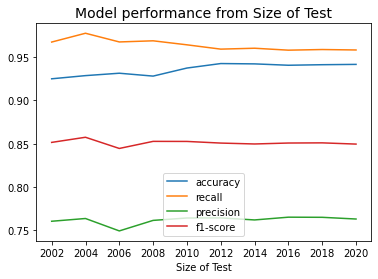

In [20]:
begin_of_ds_train = pd.to_datetime('1990-01-01')
end_of_ds_train = pd.to_datetime('1998-12-31')
begin_of_ds_test = pd.to_datetime('1999-01-01')
# end_of_ds_test = pd.to_datetime('2007-12-31')
endd = [pd.to_datetime('2001-12-31'), pd.to_datetime('2003-12-31'), pd.to_datetime('2005-12-31'), pd.to_datetime('2007-12-31'), pd.to_datetime('2009-12-31'), 
pd.to_datetime('2011-12-31'), pd.to_datetime('2013-12-31'), pd.to_datetime('2015-12-31'), pd.to_datetime('2017-12-31'), pd.to_datetime('2019-12-31')]
dic = {}
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
for e in endd:
    X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, e, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
    clf_xgb.fit(X_train, y_train)
    dic[e] = metrics(clf_xgb, X_test, y_test)

ac_temp, pr_temp, re_temp, f_temp = [], [], [], []
for e in endd:
    ac_temp.append(dic[e][0])
    pr_temp.append(dic[e][1])
    re_temp.append(dic[e][2])
    f_temp.append(dic[e][3])

fig, ax = plt.subplots()
plt.title('Model performance from Size of Test', fontsize=14)
ax.plot(endd,ac_temp, label='accuracy')
ax.plot(endd,pr_temp, label='recall')
ax.plot(endd,re_temp, label='precision')
ax.plot(endd,f_temp, label='f1-score')
plt.xlabel('Size of Test')
plt.legend()
plt.show()

### Vary *window*, *to_horizon*, *delta_in_x*

In [10]:
begin_of_ds_train = pd.to_datetime('1990-01-01')
end_of_ds_train = pd.to_datetime('1998-12-31')
begin_of_ds_test = pd.to_datetime('1999-01-01')
end_of_ds_test = pd.to_datetime('2007-12-31')

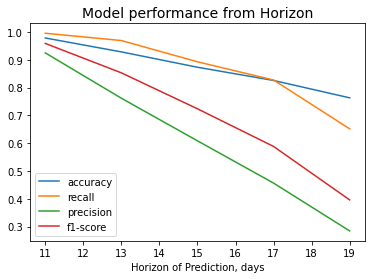

In [22]:
hor = [22, 24, 26, 28, 30]
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
dic = {}
for h in hor:
    X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=h, delta_in_x=11, station='Солонешное', added_feature=[])
    X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=h, delta_in_x=11, station='Солонешное', added_feature=[])
    clf_xgb.fit(X_train, y_train)
    dic[h] = metrics(clf_xgb, X_test, y_test)
ac_temp, pr_temp, re_temp, f_temp = [], [], [], []
for h in hor:
    ac_temp.append(dic[h][0])
    pr_temp.append(dic[h][1])
    re_temp.append(dic[h][2])
    f_temp.append(dic[h][3])

hor = np.subtract(hor, 11)
fig, ax = plt.subplots()
plt.title('Model performance from Horizon', fontsize=14)
ax.plot(hor,ac_temp, label='accuracy')
ax.plot(hor,pr_temp, label='recall')
ax.plot(hor,re_temp, label='precision')
ax.plot(hor,f_temp, label='f1-score')
plt.xlabel('Horizon of Prediction, days')
plt.legend()
plt.show()

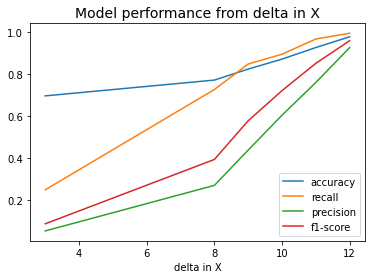

In [28]:
del_in_x = [3, 8, 9, 10, 11, 12]
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
dic = {}
for d in del_in_x:
    X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=24, delta_in_x=d, station='Солонешное', added_feature=[])
    X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=24, delta_in_x=d, station='Солонешное', added_feature=[])
    clf_xgb.fit(X_train, y_train)
    dic[d] = metrics(clf_xgb, X_test, y_test)
ac_temp, pr_temp, re_temp, f_temp = [], [], [], []
for h in del_in_x:
    ac_temp.append(dic[h][0])
    pr_temp.append(dic[h][1])
    re_temp.append(dic[h][2])
    f_temp.append(dic[h][3])

fig, ax = plt.subplots()
plt.title('Model performance from delta in X', fontsize=14)
ax.plot(del_in_x,ac_temp, label='accuracy')
ax.plot(del_in_x,pr_temp, label='recall')
ax.plot(del_in_x,re_temp, label='precision')
ax.plot(del_in_x,f_temp, label='f1-score')
plt.xlabel('delta in X')
plt.legend()
plt.show()

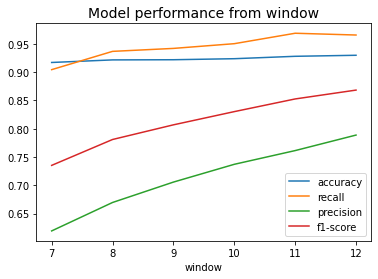

In [29]:
win = [7, 8, 9, 10, 11, 12]
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
dic = {}
for w in win:
    X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=w, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
    X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=w, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
    clf_xgb.fit(X_train, y_train)
    dic[w] = metrics(clf_xgb, X_test, y_test)
ac_temp, pr_temp, re_temp, f_temp = [], [], [], []
for h in win:
    ac_temp.append(dic[h][0])
    pr_temp.append(dic[h][1])
    re_temp.append(dic[h][2])
    f_temp.append(dic[h][3])

fig, ax = plt.subplots()
plt.title('Model performance from window', fontsize=14)
ax.plot(win,ac_temp, label='accuracy')
ax.plot(win,pr_temp, label='recall')
ax.plot(win,re_temp, label='precision')
ax.plot(win,f_temp, label='f1-score')
plt.xlabel('window')
plt.legend()
plt.show()

In [ ]:
X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

### Yearly. Vary *delta_in_x*

In [7]:
begin_of_ds_train = pd.to_datetime('1980-01-01')
end_of_ds_train = pd.to_datetime('2000-12-31')
begin_of_ds_test = pd.to_datetime('2001-01-01')
end_of_ds_test = pd.to_datetime('2010-12-31')
X_train, y_train = make_ds_add_year(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_year(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])

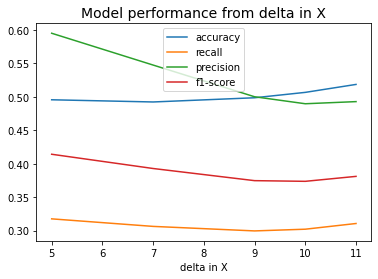

In [16]:
del_in_x = [5, 7, 9, 10, 11]
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
dic = {}
for d in del_in_x:
    X_train, y_train = make_ds_add_year(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=20, to_horizon=30, delta_in_x=d, station='Солонешное', added_feature=[])
    X_test, y_test = make_ds_add_year(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=20, to_horizon=30, delta_in_x=d, station='Солонешное', added_feature=[])
    clf_xgb.fit(X_train, y_train)
    dic[d] = metrics(clf_xgb, X_test, y_test)
ac_temp, pr_temp, re_temp, f_temp = [], [], [], []
for h in del_in_x:
    ac_temp.append(dic[h][0])
    pr_temp.append(dic[h][1])
    re_temp.append(dic[h][2])
    f_temp.append(dic[h][3])

fig, ax = plt.subplots()
plt.title('Model performance from delta in X', fontsize=14)
ax.plot(del_in_x,ac_temp, label='accuracy')
ax.plot(del_in_x,pr_temp, label='recall')
ax.plot(del_in_x,re_temp, label='precision')
ax.plot(del_in_x,f_temp, label='f1-score')
plt.xlabel('delta in X')
plt.legend()
plt.show()

10
13
15
18
20
25


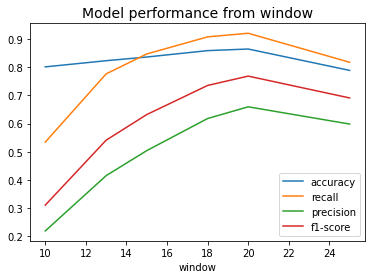

In [14]:
win = [10, 13, 15, 18, 20, 25]
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
dic = {}
for w in win:
    X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=w, to_horizon=30, delta_in_x=11, station='Солонешное', added_feature=[])
    X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=w, to_horizon=30, delta_in_x=11, station='Солонешное', added_feature=[])
    clf_xgb.fit(X_train, y_train)
    dic[w] = metrics(clf_xgb, X_test, y_test)
ac_temp, pr_temp, re_temp, f_temp = [], [], [], []
for h in win:
    ac_temp.append(dic[h][0])
    pr_temp.append(dic[h][1])
    re_temp.append(dic[h][2])
    f_temp.append(dic[h][3])

fig, ax = plt.subplots()
plt.title('Model performance from window', fontsize=14)
ax.plot(win,ac_temp, label='accuracy')
ax.plot(win,pr_temp, label='recall')
ax.plot(win,re_temp, label='precision')
ax.plot(win,f_temp, label='f1-score')
plt.xlabel('window')
plt.legend()
plt.show()

In [8]:
begin_of_ds_train = pd.to_datetime('1980-01-01')
end_of_ds_train = pd.to_datetime('2000-12-31')
begin_of_ds_test = pd.to_datetime('2001-01-01')
end_of_ds_test = pd.to_datetime('2010-12-31')
X_train, y_train = make_ds_add_year(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=20, to_horizon=30, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_year(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=20, to_horizon=30, delta_in_x=11, station='Солонешное', added_feature=[])

In [9]:
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

[0.5184275184275184,
 0.31064073226544625,
 0.4927404718693285,
 0.38105263157894737]

**Почему так сильно влияет -delta_in_x???**

1) Увеличить to_horizon в функции с учетом delta_in_x и сравнить с готовой функцией
2) Посмотреть как далеко мы можем предсказывать? Построить график Насколько далеко сохраняются хорошие метрики

In [ ]:
begin_of_ds_train = pd.to_datetime('1980-01-01')
end_of_ds_train = pd.to_datetime('2000-12-31')
begin_of_ds_test = pd.to_datetime('2001-01-01')
end_of_ds_test = pd.to_datetime('2010-12-31')
X_train, y_train = make_ds_add_new(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_new(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])

In [ ]:
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

[0.7343921139101862,
 0.27823691460055094,
 0.12484548825710753,
 0.17235494880546073]

In [ ]:
X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])

In [ ]:
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

[0.9459459459459459,
 0.9811023622047244,
 0.7700865265760197,
 0.8628808864265928]

### Check the validity of placing *delta_in_x* in *make_ds_add_feat*

In [ ]:
begin_of_ds_train = pd.to_datetime('1990-01-01')
end_of_ds_train = pd.to_datetime('1998-12-31')
begin_of_ds_test = pd.to_datetime('1999-01-01')
end_of_ds_test = pd.to_datetime('2007-12-31')

Decrease to_horizon in new function

In [ ]:
X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

[0.9281382656155246,
 0.9689265536723164,
 0.7613762486126526,
 0.8527035425730266]

In [ ]:
X_train, y_train = make_ds_add_new(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=13, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_new(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=13, delta_in_x=11, station='Солонешное', added_feature=[])
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

[0.9282020079099483,
 0.9689703808180536,
 0.7624861265260822,
 0.8534161490683231]

Increase to horizon in old function

In [ ]:
X_train, y_train = make_ds_add_new(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_new(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=24, delta_in_x=11, station='Солонешное', added_feature=[])
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

[0.687557042896258,
 0.2871287128712871,
 0.09688195991091314,
 0.14487926727726894]

In [ ]:
X_train, y_train = make_ds_add_feat(data_meteo, begin_of_ds_train, end_of_ds_train, enc, window=11, to_horizon=35, delta_in_x=11, station='Солонешное', added_feature=[])
X_test, y_test = make_ds_add_feat(data_meteo, begin_of_ds_test, end_of_ds_test, enc, window=11, to_horizon=35, delta_in_x=11, station='Солонешное', added_feature=[])
clf_xgb = xgb.XGBClassifier(n_jobs=-1, random_state=1)
clf_xgb.fit(X_train, y_train)
metrics(clf_xgb, X_test, y_test)

[0.6949666464523954,
 0.3373493975903614,
 0.12472160356347439,
 0.18211382113821137]